# 02 — EDA & Dataset Understanding
**Part B | Milestone 2**

Question: what do the EuRoC IMU + ground-truth streams look like, how is the drift label distributed, and how must we split so overlapping windows do not leak?

Figures are also written by `python scripts/run_eda.py` into `figures/eda/`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import json
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from vio_drift.data.loader import load_sequence
from vio_drift.data.align import align_imu_to_groundtruth, report_gaps

ROOT = Path.cwd().parent
FIG = ROOT / "figures" / "eda"
FIG.mkdir(parents=True, exist_ok=True)

config = yaml.safe_load((ROOT / "configs" / "config.yaml").read_text())
sequences = config["data"]["sequences"]
raw_dir = ROOT / config["data"]["raw_dir"]
processed_dir = ROOT / config["data"]["processed_dir"]
sequences

['MH_01_easy', 'MH_02_easy', 'MH_03_medium']

## Data quality

Missing values, sampling rate, timestamp gaps, alignment drop rate. IMU and ground-truth on these Machine Hall files are both ~200 Hz.

In [2]:
loaded = {}
quality_rows = []
for seq in sequences:
    imu, gt = load_sequence(raw_dir, seq)
    loaded[seq] = (imu, gt)
    gaps = report_gaps(imu, gt)
    aligned = align_imu_to_groundtruth(imu, gt)
    quality_rows.append({
        "seq_id": seq,
        "imu_rows": len(imu),
        "gt_rows": len(gt),
        "duration_s": round(gaps["imu"]["duration_s"], 3),
        "imu_rate_hz": round(gaps["imu"]["implied_rate_hz"], 3),
        "gt_rate_hz": round(gaps["ground_truth"]["implied_rate_hz"], 3),
        "imu_max_dt_s": gaps["imu"]["max_dt_s"],
        "imu_missing": int(imu.isna().sum().sum()),
        "gt_missing": int(gt.isna().sum().sum()),
        "align_dropped_pct": round(100 * (len(imu) - len(aligned)) / len(imu), 2),
    })
quality = pd.DataFrame(quality_rows)
quality

[align] dropped 431/36820 IMU rows (1.17%) with no ground-truth match within 20.0 ms
[align] dropped 400/30400 IMU rows (1.32%) with no ground-truth match within 20.0 ms
[align] dropped 698/27008 IMU rows (2.58%) with no ground-truth match within 20.0 ms


,seq_id,imu_rows,gt_rows,duration_s,imu_rate_hz,gt_rate_hz,imu_max_dt_s,imu_missing,gt_missing,align_dropped_pct
0,MH_01_easy,36820,36382,184.095,200.003,200.003,0.005,0,0,1.17
1,MH_02_easy,30400,29993,151.995,200.003,200.003,0.005,0,0,1.32
2,MH_03_medium,27008,26302,135.035,200.003,200.003,0.005,0,0,2.58


**Units (EuRoC ASL):** gyro rad/s, accel m/s² (specific force), position m, quaternion unitless, velocity m/s.

**What looks noisy vs motion:** gyro chatter at ~0.2 rad/s RMS is sensor noise plus small attitude changes. Accel sits near 9.8 m/s² in magnitude; on MH_01 the MAV is pitched so gravity is split across `ax` and `az`, not sitting on `az` alone.

## Raw IMU, trajectories, speed

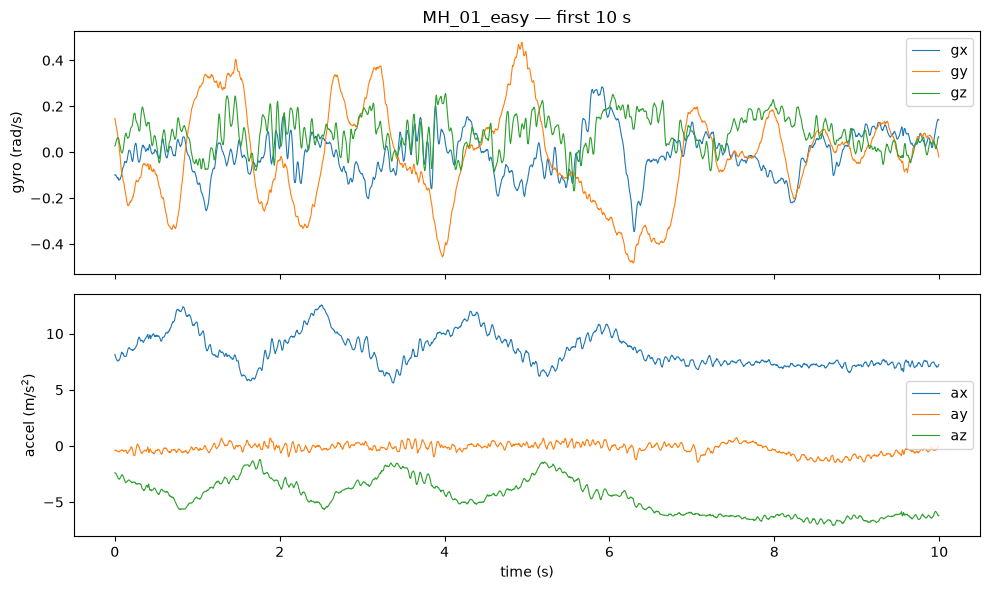

In [3]:
seq = sequences[0]
imu, _ = loaded[seq]
t = (imu["t_ns"] - imu["t_ns"].iloc[0]) / 1e9
mask = t < 10
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(t[mask], imu.loc[mask, ["gx", "gy", "gz"]], lw=0.8)
axes[0].legend(["gx", "gy", "gz"])
axes[0].set_ylabel("gyro (rad/s)")
axes[0].set_title(f"{seq} — first 10 s")
axes[1].plot(t[mask], imu.loc[mask, ["ax", "ay", "az"]], lw=0.8)
axes[1].legend(["ax", "ay", "az"])
axes[1].set_ylabel("accel (m/s$^2$)")
axes[1].set_xlabel("time (s)")
fig.tight_layout()
fig.savefig(FIG / "raw_imu_signals.png", dpi=150)
plt.show()

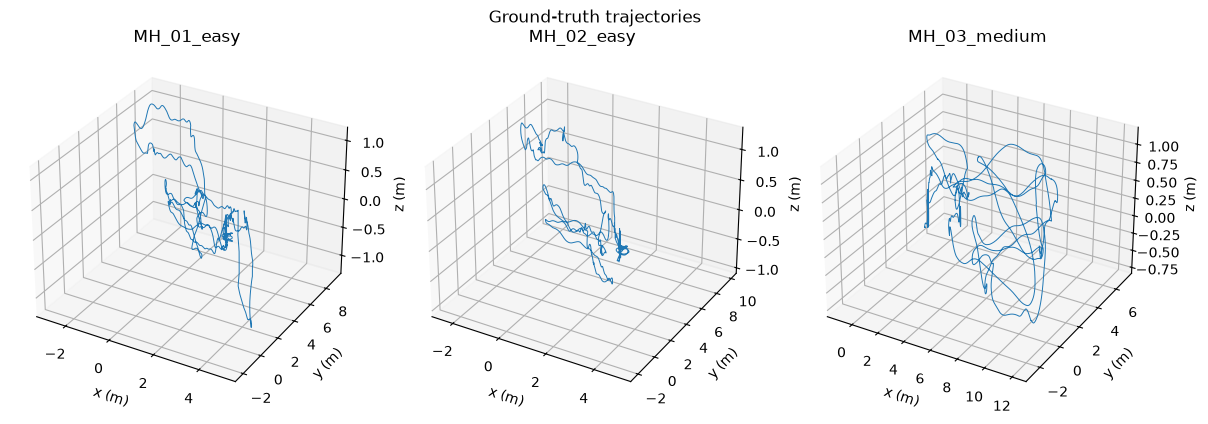

In [4]:
fig = plt.figure(figsize=(12, 4.2))
for i, seq in enumerate(sequences):
    _, gt = loaded[seq]
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    ax.plot(gt["px"], gt["py"], gt["pz"], lw=0.7)
    ax.set_title(seq)
    ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.set_zlabel("z (m)")
fig.suptitle("Ground-truth trajectories")
fig.tight_layout()
fig.savefig(FIG / "true_trajectories.png", dpi=150)
plt.show()

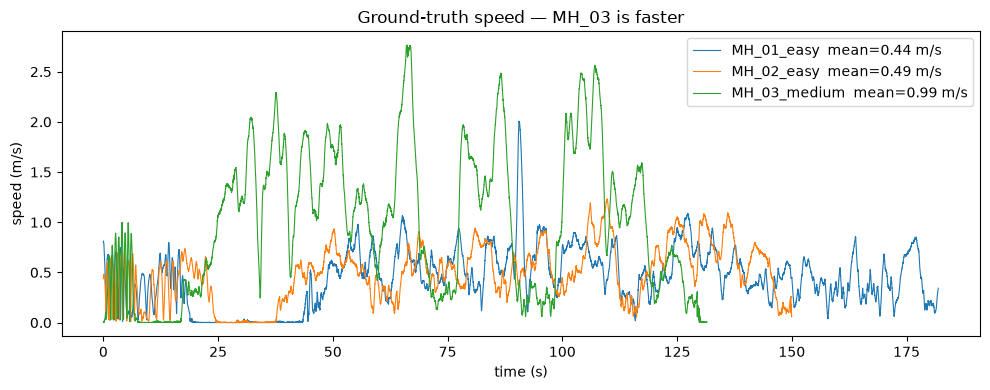

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
for seq in sequences:
    _, gt = loaded[seq]
    t = (gt["t_ns"] - gt["t_ns"].iloc[0]) / 1e9
    speed = np.linalg.norm(gt[["vx", "vy", "vz"]].to_numpy(), axis=1)
    ax.plot(t, speed, lw=0.8, label=f"{seq}  mean={speed.mean():.2f} m/s")
ax.set_xlabel("time (s)")
ax.set_ylabel("speed (m/s)")
ax.set_title("Ground-truth speed — MH_03 is faster")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "speed_comparison.png", dpi=150)
plt.show()

## Label analysis (after Part A)

Primary target: **`err_mag_m`** (raw IMU, 1 s). Also inspect `err_*_bc` and the 3-axis errors.

In [6]:
labels = pd.concat(
    [pd.read_csv(processed_dir / f"windows_{seq}.csv") for seq in sequences],
    ignore_index=True,
)
print("NaNs in labels:", int(labels.isna().sum().sum()))
print("windows per sequence:\n", labels.groupby("seq_id").size())

def describe_label(col):
    rows = []
    for seq, g in labels.groupby("seq_id"):
        s = g[col]
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        rows.append({
            "seq_id": seq, "mean": s.mean(), "std": s.std(),
            "min": s.min(), "max": s.max(), "skew": s.skew(),
            "iqr_outliers": int(((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()),
        })
    return pd.DataFrame(rows)

print("\nraw err_mag_m")
display(describe_label("err_mag_m").round(4))
print("bias-corrected err_mag_m_bc")
display(describe_label("err_mag_m_bc").round(4))

NaNs in labels: 0
windows per sequence:
 seq_id
MH_01_easy      724
MH_02_easy      596
MH_03_medium    523
dtype: int64

raw err_mag_m


,seq_id,mean,std,min,max,skew,iqr_outliers
0,MH_01_easy,0.1859,0.0119,0.1399,0.2220,-0.6442,24
1,MH_02_easy,0.1856,0.0131,0.1384,0.2153,-0.8931,30
2,MH_03_medium,0.1813,0.0205,0.0967,0.3008,0.9309,37


bias-corrected err_mag_m_bc


,seq_id,mean,std,min,max,skew,iqr_outliers
0,MH_01_easy,0.0213,0.0125,0.0036,0.0740,1.2875,18
1,MH_02_easy,0.0183,0.0106,0.0014,0.0597,1.1574,16
2,MH_03_medium,0.0300,0.0232,0.0019,0.1762,2.2924,37


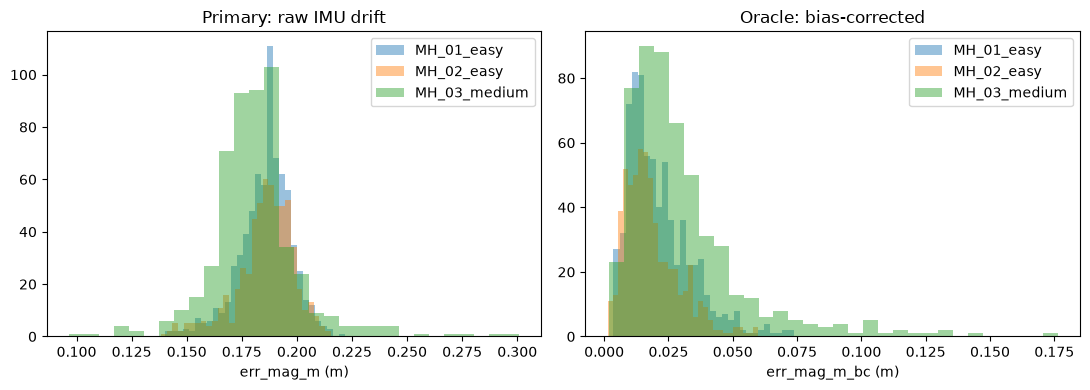

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for seq, g in labels.groupby("seq_id"):
    axes[0].hist(g["err_mag_m"], bins=30, alpha=0.45, label=seq)
    axes[1].hist(g["err_mag_m_bc"], bins=30, alpha=0.45, label=seq)
axes[0].set_title("Primary: raw IMU drift")
axes[0].set_xlabel("err_mag_m (m)")
axes[1].set_title("Oracle: bias-corrected")
axes[1].set_xlabel("err_mag_m_bc (m)")
axes[0].legend(); axes[1].legend()
fig.tight_layout()
fig.savefig(FIG / "label_distribution.png", dpi=150)
plt.show()

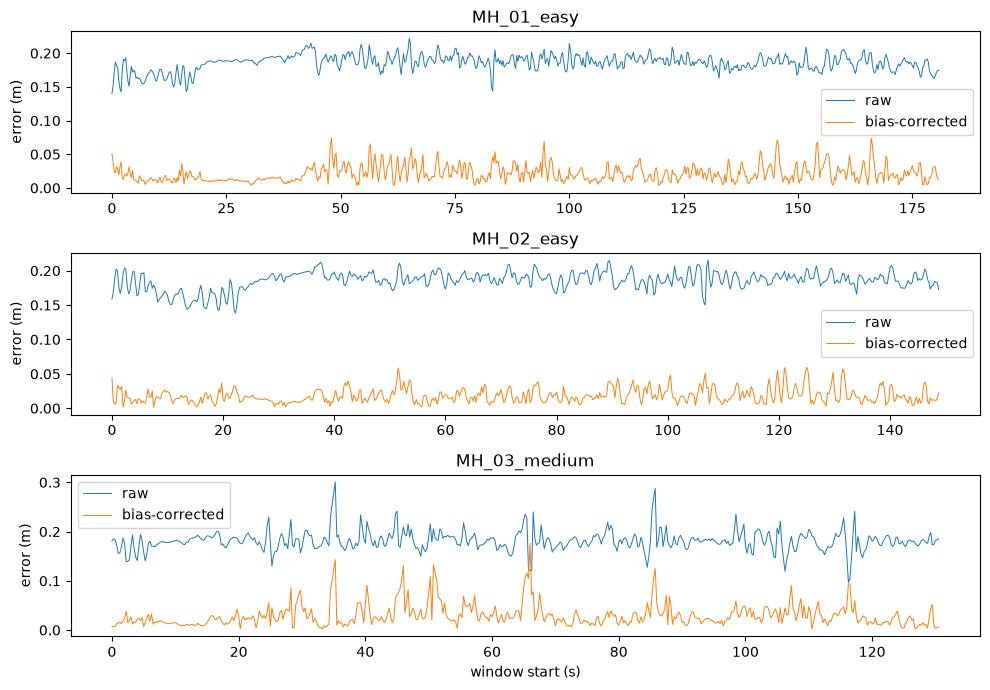

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7))
for ax, (seq, g) in zip(axes, labels.groupby("seq_id")):
    t = (g["t_start_ns"] - g["t_start_ns"].iloc[0]) / 1e9
    ax.plot(t, g["err_mag_m"], lw=0.7, label="raw")
    ax.plot(t, g["err_mag_m_bc"], lw=0.7, label="bias-corrected")
    ax.set_title(seq); ax.set_ylabel("error (m)"); ax.legend()
axes[-1].set_xlabel("window start (s)")
fig.tight_layout()
fig.savefig(FIG / "label_over_time.png", dpi=150)
plt.show()

Window-length diagnostic (Part A / D5 groundwork). Raw error grows superlinearly — bias-dominated. Bias-corrected residuals stay much smaller but still grow.

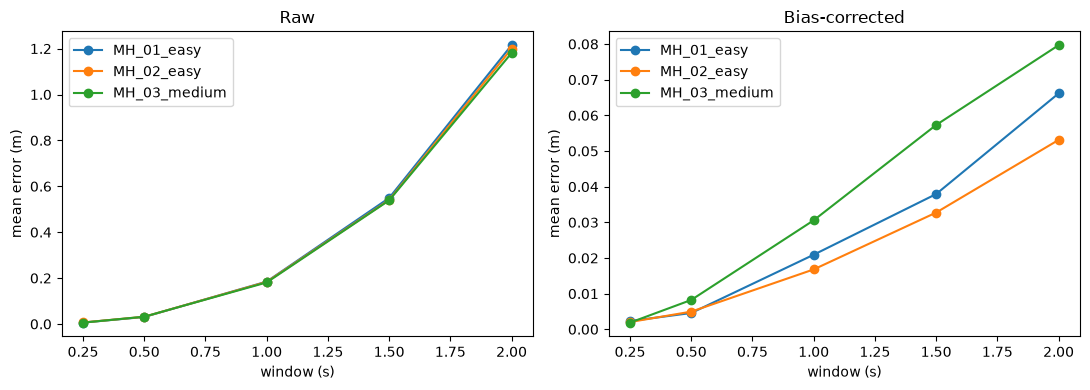

,seq_id,window_seconds,n_windows,mean_err_mag_m,mean_err_mag_m_bc
0,MH_01_easy,0.25,80,0.006185,0.002314
1,MH_01_easy,0.50,80,0.030613,0.004573
2,MH_01_easy,1.00,80,0.184730,0.020917
3,MH_01_easy,1.50,80,0.549065,0.037924
4,MH_01_easy,2.00,80,1.214877,0.066142
5,MH_02_easy,0.25,80,0.006549,0.002039
6,MH_02_easy,0.50,80,0.031427,0.004955
7,MH_02_easy,1.00,80,0.183354,0.016795
8,MH_02_easy,1.50,80,0.540445,0.032736
9,MH_02_easy,2.00,74,1.199794,0.053106


In [9]:
wl = pd.read_csv(ROOT / "results" / "diagnostics" / "window_length.csv")
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for seq, g in wl.groupby("seq_id"):
    axes[0].plot(g["window_seconds"], g["mean_err_mag_m"], marker="o", label=seq)
    axes[1].plot(g["window_seconds"], g["mean_err_mag_m_bc"], marker="o", label=seq)
axes[0].set_title("Raw"); axes[1].set_title("Bias-corrected")
for ax in axes:
    ax.set_xlabel("window (s)"); ax.set_ylabel("mean error (m)"); ax.legend()
fig.tight_layout()
fig.savefig(FIG / "error_vs_window_length.png", dpi=150)
plt.show()
wl

### Log transform?

**No for the primary target.** `err_mag_m` is a tight blob (~0.18 ± 0.01–0.02 m), slightly left-skewed on the easy sequences. A log would squash an already narrow range. `err_mag_m_bc` is right-skewed (MH_03 skew ≈ 2.3); Part D may log that comparison target if they model it, but it is not the headline label.

## Train / test split — leave one sequence out

Windows are 1.0 s long and slide every 0.25 s, so neighbours share 75% of their IMU rows. A random shuffle of windows would put almost-identical examples in train and test. **Split by sequence, never by row.**

Contract: `data/processed/splits.json`. Primary target stays `err_mag_m`.

In [10]:
splits = json.loads((processed_dir / "splits.json").read_text())
print(json.dumps(splits, indent=2))
for fold in splits["folds"]:
    overlap = set(fold["train"]) & set(fold["test"])
    assert not overlap, overlap
print("no train/test sequence overlap")

{
  "scheme": "leave_one_sequence_out",
  "reason": "Windows overlap (1.0 s length, 0.25 s stride). A random row split would put neighbouring windows in both train and test and leak the label.",
  "window_seconds": 1.0,
  "stride_seconds": 0.25,
  "primary_target": "err_mag_m",
  "axis_targets": [
    "err_dx",
    "err_dy",
    "err_dz"
  ],
  "comparison_targets": [
    "err_mag_m_bc",
    "err_dx_bc",
    "err_dy_bc",
    "err_dz_bc"
  ],
  "sequences": [
    "MH_01_easy",
    "MH_02_easy",
    "MH_03_medium"
  ],
  "folds": [
    {
      "fold_id": "leave_MH_01_easy",
      "train": [
        "MH_02_easy",
        "MH_03_medium"
      ],
      "test": [
        "MH_01_easy"
      ]
    },
    {
      "fold_id": "leave_MH_02_easy",
      "train": [
        "MH_01_easy",
        "MH_03_medium"
      ],
      "test": [
        "MH_02_easy"
      ]
    },
    {
      "fold_id": "leave_MH_03_medium",
      "train": [
        "MH_01_easy",
        "MH_02_easy"
      ],
      "test": [
  

## What we learned

- IMU and GT are ~200 Hz, no missing values. Alignment drops 1.2–2.6% of IMU rows at coverage edges.
- MH_03 is genuinely “medium”: mean speed ~1.0 m/s vs ~0.45–0.49 m/s on the easy flights; longer path (~131 m vs ~74–81 m).
- Raw 1 s drift is **bias-dominated**: mean 0.181–0.186 m, std 1–2 cm. Easy vs medium barely differs on the headline magnitude.
- After oracle bias correction, mean residual is 0.018–0.030 m and MH_03 is the widest (max 0.176 m). That is a comparison label, not the leaderboard.
- 3-axis raw errors have more spread than the magnitude — Part D should train on `dx,dy,dz` as well.
- Split: three LOSO folds. Do not log-transform `err_mag_m`.
